In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import os

Вычисление ошибок

In [ ]:
def convert_agevoxceleb_txt_to_csv(input_file, output_file=None):

    if output_file is None:
        output_file = os.path.splitext(input_file)[0] + '.csv'
    
    df = pd.read_csv(input_file, sep=' ', header=None, 
                     names=['speaker_id', 'true_age', 'predicted_age'])
    
    df.to_csv(output_file, index=False, encoding='utf-8')
    
    print(f"Файл преобразован: {output_file}")
    print(f"Всего записей: {len(df)}")
    print(f"\nПервые 5 строк:")
    print(df.head())
    
    
    return df

# Использование
if __name__ == '__main__':
    input_file = "agevoxceleb_age_predictions.txt"
    df_preds = convert_agevoxceleb_txt_to_csv(input_file)

Файл преобразован: agevoxceleb_age_predictions.csv
Всего записей: 16050

Первые 5 строк:
                  speaker_id  true_age  predicted_age
0  id00042/34f5sBShxSo/00001        70          88.44
1  id00042/34f5sBShxSo/00002        70          84.02
2  id00042/34f5sBShxSo/00003        70          80.91
3  id00042/34f5sBShxSo/00004        70          85.30
4  id00042/34f5sBShxSo/00005        70          82.88


In [3]:
df_preds.head()

,speaker_id,true_age,predicted_age
0,id00042/34f5sBShxSo/00001,70,88.44
1,id00042/34f5sBShxSo/00002,70,84.02
2,id00042/34f5sBShxSo/00003,70,80.91
3,id00042/34f5sBShxSo/00004,70,85.30
4,id00042/34f5sBShxSo/00005,70,82.88


In [4]:
df_preds.shape

(16050, 3)

In [5]:
age_counts = df_preds.groupby('true_age')['speaker_id'].count()
print(age_counts)

true_age
5      1
11     7
14     4
15    18
16    14
      ..
75    24
76    98
78    60
79     3
80    19
Name: speaker_id, Length: 68, dtype: int64


In [6]:
df_preds['error'] = df_preds['predicted_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['predicted_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['predicted_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['predicted_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     9.330 лет
RMSE (Root Mean Squared Error): 11.978 лет
Std of Error (разброс ошибок):  11.909 лет

Процент ошибок в пределах:
  ≤ 1 год:   7.0%
  ≤ 3 года:  21.2%
  ≤ 5 лет:   35.0%
  ≤ 10 лет:   62.1%

Статистика абсолютных ошибок:
  Мин ошибка:  0.000 лет
  Медиана:     7.520 лет
  Макс ошибка: 54.530 лет


Разница возрастных распределений

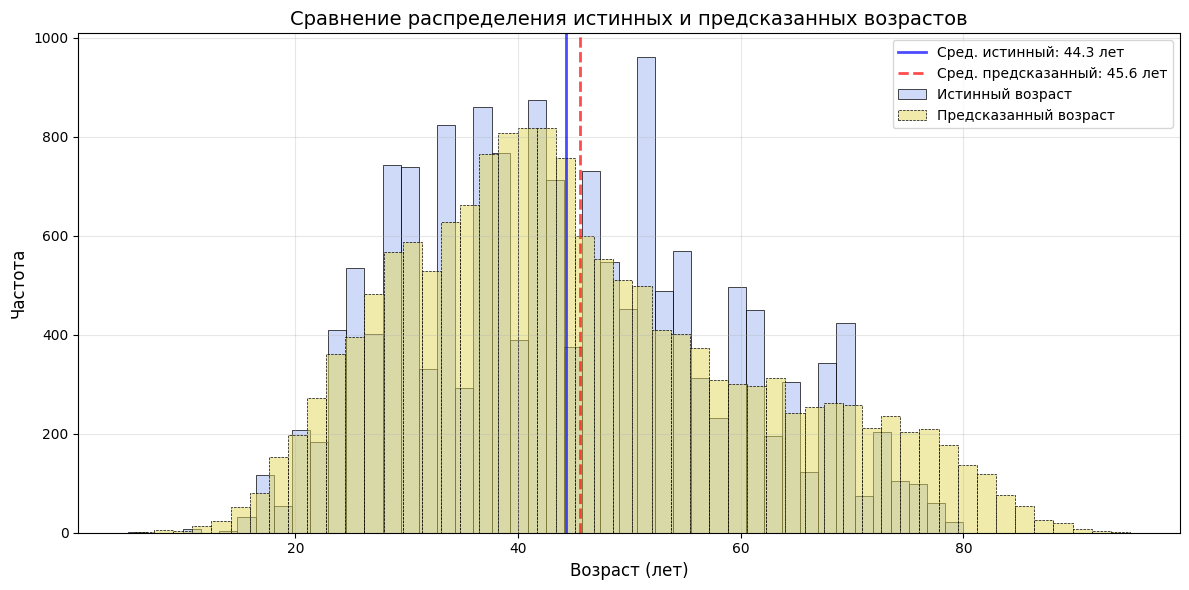

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='predicted_age',
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['predicted_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["predicted_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()